In [1]:
from functools import partial
import random
import pandas as pd
import numpy as np
from collections import deque, defaultdict
from sortedcontainers import SortedDict
from abc import ABC, abstractmethod
import asyncio
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

## Order book simulation project

#### Contents

- [Changelog](#section_1)
- [Classes](#section_2)
- [Real-time market](#section_3)
- [Debugging](#section_4)

<a id="section_1"></a>
### Changelog

**11 Apr 2026**
- Began work on ZeroMQ architecture implementation in VSC

**10 Apr 2026**
- Implemented asyncio simulation loop

**9 Apr 2026**
- Created OrderQueue class, doubly linked-list
- Changed implementation of order storage queues from deques to doubly linked-list
- Fixed bugs around queues not being deleted properly when empty

**7 Apr 2026**
- Created market noise class
- Updated compute imbalance function and added sigmoid function to OrderBook class to make imbalance impact on orders nonlinear
- Moved calculation and logging of data to analytics class
- Added live market in asyncio

**6 Apr 2026**:
- Created order class
- Created order factory class
- Updated orderbook internals to accommodate new classes
- Updated syntax for SortedDict functions to match newer, not deprecated syntax
- Added floor for sampling price so asset price cannot go negative
- Updated update mid function to better refkect empty book conditions
- Worked on order loops to attempt to fix correlation between impact and spread.
- Impact and spread correlation are preserved (ish) when you look at observations that have both sides of the book. Turned out that the observations where there was impact while having < 1 book penet was because of an empty half of the book, so you have to isolate out or treat these numbers before you can see the true stats.

**2 Apr 2026**:
- Changed bid and ask book data structure to SortedDict from sortedcontainers library. Keys maintained in a Balanced BST, giving O(logN) insertions and O(1) access to best bid / ask
- Fixed limit orders having higher impact than market

**26 Mar 2026**
- Created Analytics class

**25 Mar 2026**
- Created MarketNoise class

**23 Mar 2026**
- Created Orderbook class

<a id="section_2"></a>
### Classes

#### Orders

In [7]:
class Order(ABC):
    def __init__(self, side, quantity, orderid):
        self.side = side
        self.quantity = quantity
        self.orderid = orderid

    @abstractmethod
    def get_details(self):
        pass

    @abstractmethod
    def get_type(self):
        pass
        
    def get_side(self):
        return self.side
    def get_quantity(self):
        return self.quantity
    def get_orderid(self):
        return self.orderid

class LimitOrder(Order):
    def __init__(self, side, quantity, orderid, price):
        super().__init__(side, quantity, orderid) 
        self.price = price
    def get_type(self):
        return f"Limit"
    def get_price(self):
        return self.price
    def get_details(self):
        return f"Limit {self.side} order at {self.price} of {self.quantity}"

class MarketOrder(Order):
    def __init__(self, side, quantity, orderid):
        super().__init__(side, quantity, orderid)
    def get_type(self):
        return f"Market"
    def get_details(self):
        return f"Market {self.side} order of {self.quantity}" 

class OrderFactory:
    @staticmethod        
    def create_market_order(side, quantity, orderid):
        if quantity <= 0:
            raise ValueError("Quantity must be greater than zero.")
        if side.upper() not in ["BUY", "SELL"]:
            raise ValueError("Side must be either buy or sell.")
        return MarketOrder(side, quantity, orderid)
    
    @staticmethod
    def create_limit_order(side, quantity, orderid, price):
        if quantity <= 0:
            raise ValueError("Quantity must be greater than zero.")
        if price <= 0:
            raise ValueError("Price must be greater than zero.")
        if side.upper() not in ["BUY", "SELL"]:
            raise ValueError("Side must be either buy or sell.")
        return LimitOrder(side, quantity, orderid, price)

#### Order-queue

In [9]:
class Node:
    def __init__(self, order = None):
        self.stored_order = order
        self.prev = None
        self.next = None

        # list index stored to facilitate O(1) cancels of random MarketNoise orders which do not track order_id.
        # when orders are fully filled, this list_index will be used to pop the node from the list 
        self.list_index = None

class OrderQueue:
    def __init__(self):
        # initialise markers for the starting node and ending node
        # head node and tail node will hold no orders
        self.head = Node()
        self.tail = Node()
        self.head.next = self.tail
        self.tail.prev = self.head

        self.total_volume = 0
        self.count = 0
        self.last_order = None

        # Node list to facilitate O(1) cancels of random MarketNoise orders which do not track order_id.
        self.node_list = []

    def remove_node(self, node):
        if not node or node.stored_order is None:
            print(f"Removal failed. Order not found")
            return

        index = node.list_index
        quantity = node.stored_order.quantity
        
        node.prev.next, node.next.prev = node.next, node.prev

        if index is not None:
            self.node_list[index] = self.node_list[-1]
            self.node_list[index].list_index = index
            self.node_list.pop()

        self.total_volume -= quantity
        self.count -= 1

        node.stored_order, node.list_index = None, None
        node.prev, node.next = None, None

    def add_order(self, order):
        new_node = Node(order)

        # access node before tail node
        last_real_node = self.tail.prev
        new_node.next = self.tail
        new_node.prev = last_real_node
        last_real_node.next = new_node
        self.tail.prev = new_node

        self.total_volume += order.quantity
        self.count += 1

        return new_node

    def add_order_MN(self, order):
        new_node = self.add_order(order)
        new_node.list_index = len(self.node_list)
        self.node_list.append(new_node)

    def fill_order(self, fill_quantity):
        if self.total_volume == 0:
            print(f'Queue is empty. Unable to fill')
            return
        if fill_quantity > self.head.next.stored_order.quantity:
            print(f'Sitting order has insufficient quantity to fill.')
            
        self.head.next.stored_order.quantity -= fill_quantity
        self.total_volume -= fill_quantity

        # fully filled logic
        if self.head.next.stored_order.quantity == 0:
            self.remove_node(self.head.next)

    def cancel_index(self, index):
        if index > len(self.node_list) - 1:
            print(f"Cancellation failed. Index out of range")
            return

        node = self.node_list[index]
        self.remove_node(node)

#### Orderbook

In [11]:
class OrderBook:
    def __init__(self, mid=100):

        # bid and ask book reflected as sorted dictionaries holding deques
        # deques will hold the orders (which are implemented as dictionaries)
        self.bids = SortedDict()
        self.asks = SortedDict()
        self.orders_on_book = {}
        self.trades_done = defaultdict(deque)
        self.tick_size = 0.01
        
        self.mid = self.to_tick(mid)
        self.last_valid_spread = self.to_tick(self.tick_size * 2)
        self.last_exec_price = None
        self.order_id = 1
        self.book_vols = {"bids":0,
                          "asks":0}
        
        self.analytics = Analytics()
        self.order_factory = OrderFactory()
    
    def best_bid(self):
        """
        Returns best bid
        """
        return self.bids.peekitem(-1)[0] if self.bids else None

    def best_ask(self):
        """
        Returns best ask
        """
        return self.asks.peekitem(0)[0] if self.asks else None

    def get_bid_quantity(self):
        """
        Returns volume of existing bids
        """
        total = 0
        for queue in self.bids.values():
            total += queue.total_volume
        return total

    def get_ask_quantity(self):
        """
        Returns volume of existing asks
        """
        total = 0
        for queue in self.asks.values():
            total += queue.total_volume
        return total

    def get_toplevel_quantity(self, book):
        return self.asks.peekitem(0)[1].total_volume if book == "asks" else self.bids.peekitem(-1)[1].total_volume
        
    def update_mid(self):
        """
        Updates mid price
        Note that you are operating in ticks, so no conversion needed
        """
        best_bid = self.best_bid()
        best_ask = self.best_ask()

        # Standard book
        if best_bid is not None and best_ask is not None:
            self.mid = (best_bid + best_ask) / 2
            self.last_valid_spread = best_ask - best_bid
        # asks wiped out by large buy order
        elif best_bid is not None:
            #spread = getattr(self, 'last_valid_spread', fixed_spread)
            if self.last_exec_price is not None:
                self.mid = (best_bid + self.last_exec_price) / 2
            else:
                self.mid = best_bid + (self.last_valid_spread / 2)
        # bids wiped out by large sell order
        elif best_ask is not None:
            #spread = getattr(self, 'last_valid_spread', fixed_spread)
            if self.last_exec_price is not None:
                self.mid = (best_ask + self.last_exec_price) / 2
            else:
                self.mid = max(0, best_ask - (self.last_valid_spread / 2))
        else:
            pass

    def round_to_tick(self, price):
        return round(round(price / self.tick_size) * self.tick_size, 2)
    
    def to_tick(self, price):
        return round(price / self.tick_size)
    
    def to_price(self, price_in_ticks):
        return round(price_in_ticks * self.tick_size, 2)
    
    def add_limit(self, side, price, qty):
        """
        Creates a limit order dictionary and adds it to the relevant book.
        Note that prices have to be stored in ticks
        """
        order = self.order_factory.create_limit_order(side, qty, self.order_id, self.to_tick(price))
        self.last_exec_price = None
        
        event = "limit"
        executed_qty = 0

        bid_before = self.best_bid()
        ask_before = self.best_ask()
        mid_before = self.mid
        order_init_qty = order.quantity
        avg_prices = []
        signed_qty = order_init_qty if side == "buy" else -order_init_qty

        ## FOR DEBUGGING ##
        try:
            best_quote_vol = self.get_toplevel_quantity("asks") if order.side == "buy" else self.get_toplevel_quantity("bids")
            book_penetration = order_init_qty / best_quote_vol
        except:
            book_penetration = None
        ## FOR DEBUGGING ##

        
        if order.side == "buy":
            cross_idx = self.asks.bisect_right(order.price)
            marketable_prices = list(self.asks.keys()[:cross_idx])

            for level_price in marketable_prices:
                if order.quantity <= 0: 
                    break
                
                queue = self.asks[level_price]
            
                while order.quantity > 0 and queue.total_volume > 0:
                    order_on_book = queue.head.next.stored_order
                    trade = min(order.quantity, order_on_book.quantity)
                    queue.fill_order(trade)
                    self.book_vols["asks"] -= trade
                    order.quantity -= trade
                    executed_qty += trade

                    avg_prices.append((level_price, trade))
                        
                if queue.total_volume == 0:
                    self.asks.popitem(0)

                self.last_exec_price = level_price
                     
        else:                                      # append sells to ask book
            cross_idx = self.bids.bisect_left(order.price)
            marketable_prices = list(self.bids.keys()[cross_idx:])            

            for level_price in reversed(marketable_prices):
                if order.quantity <= 0: 
                    break
                
                queue = self.bids[level_price]
            
                while order.quantity > 0 and queue.total_volume > 0:
                    order_on_book = queue.head.next.stored_order
                    trade = min(order.quantity, order_on_book.quantity)
                    queue.fill_order(trade)
                    self.book_vols["bids"] -= trade
                    order.quantity -= trade
                    executed_qty += trade

                    avg_prices.append((level_price, trade))
                        
                if queue.total_volume == 0:
                    self.bids.popitem(-1)

                self.last_exec_price = level_price

        bid_after = self.best_bid()
        ask_after = self.best_ask()

        self.update_mid()
        mid_intermed = self.mid
        
        if order.quantity > 0:
            target_book = self.bids if order.side == "buy" else self.asks
            if order.price not in target_book:
                target_book[order.price] = OrderQueue()
            target_book[order.price].add_order_MN(order)
            self.book_vols["bids" if order.side == "buy" else "asks"] += order.quantity

        self.update_mid()
        
        if executed_qty:
            self.trades_done[order.price].append({"id": self.order_id, "qty": executed_qty, "close type": "limit"})
            exec_order_size = sum(exec_price * exec_qty for exec_price, exec_qty in avg_prices)
            total_exec_qty = sum(exec_qty for _, exec_qty in avg_prices)
            avg_price = exec_order_size / total_exec_qty if total_exec_qty != 0 else 0
        
            self.output_analytics(self.order_id, self.analytics, event, order.side, order_init_qty, executed_qty, avg_price, 
                                  bid_before, bid_after, ask_before, ask_after, mid_before, mid_intermed, signed_qty, book_penetration)
        
        self.order_id += 1
        
    def market_order(self, side, qty):
        """
        Executed market order against existing books
        Returns a list of trades done
        """
        book = self.asks if side == "buy" else self.bids   # execute buys against ask side, sells against bids
        self.last_exec_price = None

        order = self.order_factory.create_market_order(side, qty, self.order_id)
        event = "market"
        mid_before = self.mid
        order_init_qty = order.quantity
        signed_qty = order_init_qty if side == "buy" else -order_init_qty
        bid_before = self.best_bid()
        ask_before = self.best_ask()

        ## FOR DEBUGGING ##
        try:
            best_quote_vol = self.get_toplevel_quantity("asks") if order.side == "buy" else self.get_toplevel_quantity("bids")
            book_penetration = order_init_qty / best_quote_vol
        except:
            book_penetration = None
        ## FOR DEBUGGING ##
        
        trades = []

        executed_qty = 0
        avg_prices = []
        
        if side == "sell":
            while order.quantity > 0 and self.bids:
                p, queue = self.bids.peekitem(-1)
                while queue.total_volume > 0 and order.quantity > 0:
                    order_on_book = queue.head.next.stored_order   
                    trade = min(order_on_book.quantity, order.quantity) # minimum of the quantity of top of book price or the order size 

                    queue.fill_order(trade)  # subtract trade quantity from the top of book quantity
                    order.quantity -= trade           # subtract the trade quantity from the market order quantity
                    self.book_vols["bids"] -= trade
                    executed_qty += trade
                    avg_prices.append((p , trade))
    
                if queue.total_volume == 0: # delete price on book if no more quantity
                    self.bids.popitem(-1)

                self.last_exec_price = p

        elif side == "buy":
            while order.quantity > 0 and self.asks:
                p, queue = self.asks.peekitem(0)
                while queue.total_volume and order.quantity > 0:
                    order_on_book = queue.head.next.stored_order   # market order executes against available quantity of top of book
                    trade = min(order_on_book.quantity, order.quantity) # minimum of the quantity of top of book price or the order size 

                    queue.fill_order(trade)  # subtract trade quantity from the top of book quantity
                    order.quantity -= trade           # subtract the trade quantity from the market order quantity
                    self.book_vols["asks"] -= trade
                    executed_qty += trade
                    avg_prices.append((p , trade))
    
                if queue.total_volume == 0: # delete price on book if no more quantity
                    self.asks.popitem(0)

                self.last_exec_price = p
                    
        bid_after = self.best_bid()
        ask_after = self.best_ask()
        
        self.update_mid()
        mid_after = self.mid

        if executed_qty:
            
            self.trades_done[p].append({"id": self.order_id, "qty": executed_qty, "close type": "market"})
            exec_order_size = sum(exec_price * exec_qty for exec_price, exec_qty in avg_prices)
            total_exec_qty = sum(exec_qty for _, exec_qty in avg_prices)
            avg_price = exec_order_size / total_exec_qty if total_exec_qty != 0 else 0
            
            self.output_analytics(self.order_id, self.analytics, event, order.side, order_init_qty, executed_qty, avg_price, 
                                  bid_before, bid_after, ask_before, ask_after, mid_before, mid_after, signed_qty, book_penetration)
        
        self.order_id += 1

    def cancel_side(self, side):
        """
        Cancels orders on a specific side of the order book.
        This function is used to implement cancels from the MarketNoise class
        So there will be no id required
        """
        book = self.bids if side == "buy" else self.asks
    
        if not book:
            return
        
        price = np.random.choice(list(book.keys()))
        queue = book[price]
    
        if queue.count > 1:
            idx = random.randint(0, len(queue.node_list) - 1)
            queue.cancel_index(idx)
        elif queue.count == 1:
            queue.cancel_index(0)
        elif queue.count == 0:
            print("error. empty queue selected.")
            
        if queue.total_volume == 0:
            del book[price]

        self.update_mid()

    def sample_price(self, side):
        """
        Samples the order book. Used to control the distribution of incoming limit orders around the current book.
        Note that you are operating in ticks internally
        Think that this should be put under a separate market class.
        """
        mid = self.mid
        best_bid_ticks = self.best_bid()
        best_ask_ticks = self.best_ask()
        
        spread = (best_ask_ticks - best_bid_ticks) if best_ask_ticks and best_bid_ticks else 100

        if np.random.rand() < 0.02:
            if side == "buy" and best_ask_ticks:
                return self.to_price(best_ask_ticks)  # crosses
            elif side == "sell" and best_bid_ticks:
                return self.to_price(best_bid_ticks)

        # draw from geometric distribution. Returns the number of trials it took to get first success given probability p.
        # note that this is in ticks
        offset = min(np.random.geometric(0.2), 10) / 0.01

        # buffer to widen spread. If there is no market maker, spreads should be wider
        buffer = 20
        
        if side == "buy":
            price_in_ticks = max(mid - (offset + buffer), 100 * self.tick_size)
        else:
            price_in_ticks = max(mid + (offset + buffer), 100 * self.tick_size)
        return self.to_price(price_in_ticks)

    def compute_imbalance(self, depth=2):   # set depth = 2 first because we're using discrete prices
        """
        Calculates the current imbalance between the bid and ask sides of the order book.
        Used to control the exponential distribution of order intervals.
        Depth 2 is good for discrete price grids, as level 1 imbalance (just best bid/ask) is often
        too noisy. Looking too deep into the book includes spoofed orders that might never execute.
        """

        if not self.bids and not self.asks:
            return 0
        elif not self.bids:
            return -1
        elif not self.asks:
            return 1
        
        bid_prices = self.bids.keys()[-depth:][::-1]
        ask_prices = self.asks.keys()[:depth]

        bid_vol = sum(self.bids[p].total_volume for p in bid_prices)
        ask_vol = sum(self.asks[p].total_volume for p in ask_prices)
            
        # Linear imbalance. Real markets are non-linear though.
        # i.e. imbalance of 0.8 is exponentially more predictive of a price move than imbalance of 0.2
        return (bid_vol - ask_vol) / (bid_vol + ask_vol)

    def sigmoid_imbalance(self, k = 7):
        """
        Calculates imbalance transformed by sigmoid function.
        In the nonlinear imbalance, small fluctuations will not cause market intensities to jump
        erratically. Flat part of sigmoid around zero acts as filter for noise.
        Function has a range from -1 to 1
        k is the steepness parameter. Low k (1 - 3) makes the model behave almost linearly. Good for
        slow, low-vol markets. High k (7 - 15) makes the model twitchy. Intensity stays near the mean
        until the imbalance becomes significant, then it spikes instantly. This is more characteristic
        of volatile stocks during earnings calls.
        Set k = 7 to have an S curve where intensity grows slowly at first, then acccelerates rapidly
        as imbalance crosses +/- 0.3
        """
        return 1 / (1 + np.exp(-k * self.compute_imbalance()))
    
    def output_analytics(self, order_id, analytics, event, side, order_init_qty, 
                         executed_qty, avg_price, bid_before, bid_after, ask_before, ask_after, mid_before, mid_after, signed_qty, book_penetration):
        self.analytics.log_trade(order_id, analytics, event, side, order_init_qty, 
                         executed_qty, avg_price, bid_before, bid_after, ask_before, ask_after, mid_before, mid_after, signed_qty, book_penetration)

    def trades_df(self):
        return pd.DataFrame(self.analytics.records)

In [12]:
class Analytics:
    def __init__(self):
        self.records = []
        self.tick_size = 0.01

    def to_tick(self, price):
        return round(price / self.tick_size)
    
    def to_price(self, price_in_ticks):
        return round(price_in_ticks * self.tick_size, 2)
        
    def log_trade(self, order_id, analytics, event, side, order_init_qty, 
                  executed_qty, avg_price, bid_before, bid_after, ask_before, ask_after, mid_before, mid_after, signed_qty, book_penetration):
        if side == "buy":
            direction = 1
        else: 
            direction = -1
        impact = self.to_price(direction * (mid_after - mid_before))
        data = {"order_id" : order_id,
                "event": event,
               "side": side,
               "qty": order_init_qty,
               "filled_qty": executed_qty,
                "fill_ratio": executed_qty / order_init_qty,
                "avg_price": self.to_price(avg_price),
                "bid_before": bid_before,
                "bid_after": bid_after,
                "ask_before": ask_before,
                "ask_after": ask_after,
                "mid_before": self.to_price(mid_before),
                "mid_after": self.to_price(mid_after),
                "slippage": self.to_price(direction * (avg_price - mid_before)),
                "impact": impact,
                "impact per unit": impact / executed_qty,
                "signed_qty": signed_qty,
                "book_penet": book_penetration
               }
        self.records.append(data)

#### Market Noise

In [14]:
class MarketNoise:
    def calibrate_limit_orders(self, book, mean = 0.3, scaling = 0.5, k = 7):
        """
        Calibrates probability for limit orders to be sent
        s_val is the imbalance transformed by the sigmoid function. It will be 0.5 when the book is balanced,
        > 0.5 when there are more bids (buy pressure), and < 0.5 when there are more asks (sell pressure)
        Low imbalance makes λ_limit_buy higher, encouraging more limit buy orders to be sent
        High imbalance makes λ_limit_sell higher, encouraging more limit sell orders to be sent
        This dynamic adds mean-reverting force for liquidity creation: orders re placed against
        current trend to stabilise the book
        """
        s_val = book.sigmoid_imbalance(k)
        self.λ_limit_buy = mean + scaling * (1 - s_val)
        self.λ_limit_sell = mean + scaling * s_val
        
    def calibrate_market_orders(self, book, mean = 0.1, scaling = 3, k = 7):
        """
        Calibrates probability for market orders to be sent.
        s_val is the imbalance transformed by the sigmoid function. It will be 0.5 when the book is balanced,
        > 0.5 when there are more bids (buy pressure), and < 0.5 when there are more asks (sell pressure)
        Max(0, f(s_val)) is used to shift the function such that at 0 imbalance, only the mean is added.
        At max imbalance, the scaling is added.
        Low imbalance makes λ_market_sell higher, encouraging more market sell orders to be sent
        High imbalance makes λ_market_buy higher, encouraging more market buy orders to be sent
        This dynamic simulates momentum / herding behaviour. Market orders follow imbalance, potentially
        leading to price trends
        """
        s_val = book.sigmoid_imbalance(k)
        self.λ_market_buy = mean + scaling * max(0, (s_val - 0.5) * 2)
        self.λ_market_sell = mean + scaling * max(0, (0.5 - s_val) * 2)

    def calibrate_cancels(self, book, mean = 0.2, scaling = 0.8, k = 7):
        """
        Calibrates probability for limit orders on book to be cancelled.
        s_val is the imbalance transformed by the sigmoid function. It will be 0.5 when the book is balanced,
        > 0.5 when there are more bids (buy pressure), and < 0.5 when there are more asks (sell pressure)
        Low imbalance makes λ_cancel_buy higher, encouraging more buy orders to be cancelled
        High imbalance makes λ_cancel_sell higher, encouraging more sell orders to be cancelled
        This dynamic simulates order book fragility. When the market moves against a side, that side's
        liquidity tends to disappear, which can accelerate price movements
        """
        s_val = book.sigmoid_imbalance(k)
        self.λ_cancel_buy  = mean + scaling * max(0, (0.5 - s_val) * 2)
        self.λ_cancel_sell = mean + scaling * max(0, (s_val - 0.5) * 2)
    
    def calibrate_probabilities(self):
        self.events = [
            "limit_buy","limit_sell",
            "market_buy","market_sell",
            "cancel_buy","cancel_sell"
        ]
    
        self.lambdas = [
            self.λ_limit_buy, self.λ_limit_sell,
            self.λ_market_buy, self.λ_market_sell,
            self.λ_cancel_buy, self.λ_cancel_sell
        ]
        self.probs = np.array(self.lambdas) / max(sum(self.lambdas), 1e-9)
    
    def sample_probability(self):
        return np.random.choice(self.events, p=self.probs)

    def limit_order(self, side, book, mean = 3, sigma = 1):
        """
        Limit orders function uses normally distributed random values for quantity
        This is to reflect the nature that limit orders are usually more consistent
        Market makers / patient traders often trade in standardised blocks of order sizes
        """
        if side == "buy":
            price = book.sample_price("buy")
            qty = max(1, int(np.random.normal(mean, sigma)) + 1)
            book.add_limit("buy", price, qty)
        else:
            price = book.sample_price("sell")
            qty = max(1, int(np.random.normal(mean, sigma)) + 1)
            book.add_limit("sell", price, qty)

    def market_order(self, side, book, mean = 3, sigma = 1):
        """
        Market orders function uses lognormally distributed random values for quantity
        In real markets, the distribution of market orders has a small mean, but wide tails
        in which massive orders from whales occasionally sweep the books
        """
        if side == "buy":
            qty = max(1, int(np.random.lognormal(mean, sigma)) + 1)
            book.market_order("buy", qty)
        else:
            qty = max(1, int(np.random.lognormal(mean, sigma)) + 1)
            book.market_order("sell", qty)

    def order_cancel(self, side, book):
        if side == "buy":
            book.cancel_side("buy")
        else:
            book.cancel_side("sell")
    
    def setup_events_map(self):
        self.events_map = {"limit_buy": partial(self.limit_order, "buy", book),
              "limit_sell": partial(self.limit_order, "sell", book),
              "market_buy": partial(self.market_order, "buy", book),
              "market_sell": partial(self.market_order, "sell", book),
              "cancel_buy": partial(self.order_cancel, "buy", book),
              "cancel_sell": partial(self.order_cancel, "sell", book)
             }
    
    def simulation(self, book, t = 0, T = 10_000):
        """
        Runs a market simulation
        dt varies with lambdas, meaning it changes as imbalance spikes and intensities increase
        As summation(lambda) increases, dt gets smaller. Thus, more events occur per period during
        periods of high volatility.
        """
        
        order_times = []
        order_events = []
        order_intervals = []
        mid_series = []
        self.setup_events_map()
        
        while t < T:
            self.calibrate_limit_orders(book)
            self.calibrate_market_orders(book)
            self.calibrate_cancels(book)
            self.calibrate_probabilities()
        
            dt = np.random.exponential(1 / sum(self.lambdas))
            t += dt
            event_key = self.sample_probability()

            self.events_map[event_key]()    

            order_times.append(t)
            order_events.append(event_key)
            order_intervals.append(dt)
        
            mid_series.append(book.to_price(book.mid))

        return order_times, order_events, order_intervals, mid_series

<a id="section_3"></a>
### Real-time market

#### Asyncio

In [26]:
class AsyncExchange:
    def __init__(self, book, market_noise):
        self.book = book
        self.market_noise = market_noise
        self.order_queue = asyncio.Queue()
        self.running = True
        self.history = []

    async def market_sim_debug(self):
        print("DEBUG: Noise Task Started")
        while self.running:
            # force yield so that CPU is not hogged by marketnoise
            await asyncio.sleep(0.01) 
            
            self.market_noise.calibrate_limit_orders(self.book)
            self.market_noise.calibrate_market_orders(self.book)
            self.market_noise.calibrate_cancels(self.book)
            self.market_noise.calibrate_probabilities()
            self.market_noise.setup_events_map()

            total_lambda = sum(self.market_noise.lambdas)
            
            # If lambdas are 0, the simulation can't move.
            if total_lambda <= 0:
                print("DEBUG: Lambdas are 0! Waiting...")
                await asyncio.sleep(1.0)
                continue

            event_key = self.market_noise.sample_probability()
            
            await self.order_queue.put({"type": event_key})
            # print(f"DEBUG: Noise fired {event_key}") # Uncomment to see fire rate

    async def exchange_worker_debug(self):
        print("DEBUG: Worker Task Started")
        while self.running:
            # We use wait_for to prevent the worker from hanging forever
            try:
                order = await asyncio.wait_for(self.order_queue.get(), timeout=1.0)
                event_type = order.get("type")
                
                # Execute
                self.market_noise.events_map[event_type]()
                
                self.order_queue.task_done()
                # print(f"DEBUG: Worker executed {event_type}")
            except asyncio.TimeoutError:
                continue # Just loop back and wait again

    async def live_dashboard_debug(self, refresh_rate=1.0):
        print("DEBUG: Dashboard Task Started")
        while self.running:
            await asyncio.sleep(refresh_rate)
            df = self.book.trades_df()
            
            if df.empty:
                print("DEBUG: Dashboard sees 0 trades. Is the worker moving?")
                continue
                
            clear_output(wait=True)
            print(f"TRADES LOGGED: {len(df)} | CURRENT MID: {self.book.to_price(self.book.mid)}")
            
            # Simple plot to test if Matplotlib is the issue
            plt.figure(figsize=(8, 3))
            plt.style.use('dark_background')
            #plt.plot(df['mid_after'].tail(100).values)
            plt.plot(df['mid_after'])
            plt.show()

    async def live_dashboard_debug_2(self, refresh_rate=0.2):
        plt.ion()
        
        while self.running:
            try:
                bid_qtys = self.book.book_vols["bids"]
                ask_qtys = self.book.book_vols["asks"]
            except (RuntimeError, KeyError):
                # Catch potential race conditions if the book updates while we copy
                await asyncio.sleep(0.01)
                continue
            
            if not self.book.bids or not self.book.asks:
                await asyncio.sleep(refresh_rate)
                continue

            bid_prices_rev = bid_prices[::-1]
            bid_cum_vol = np.cumsum(bid_qtys[::-1])
        
            ask_cum_vol = np.cumsum(ask_qtys)
            
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 6))
    
            # Bid Wall (Green)
            ax.step(bid_prices_rev, bid_cum_vol, where='pre', color='green', lw=1.5, label='Bids')
            ax.fill_between(bid_prices_rev, bid_cum_vol, step="pre", color='green', alpha=0.1)
    
            # Ask Wall (Red)
            ax.step(ask_prices, ask_cum_vol, where='post', color='red', lw=1.5, label='Asks')
            ax.fill_between(ask_prices, ask_cum_vol, step="post", color='red', alpha=0.1)
    
            # 4. Zoom and Stats
            best_bid = bid_prices[-1]
            best_ask = ask_prices[0]
            mid = (best_bid + best_ask) / 2
            
            ax.set_xlim(mid * 0.998, mid * 1.002) # Narrow zoom for HFT feel
            ax.set_title(f"Order Book Depth | Spread: {best_ask - best_bid:.2f} | Mid: {mid:.2f}")
            ax.set_ylabel("Total Contracts")
            ax.legend()
    
            display(fig)
            plt.close(fig)
    
            await asyncio.sleep(refresh_rate)
            
    async def run_simulation(self):
        
        tasks = [
        asyncio.create_task(self.market_sim_debug()),
        asyncio.create_task(self.exchange_worker_debug()),
        asyncio.create_task(self.live_dashboard_debug())
        ]

        try:
            await asyncio.gather(*tasks)
        except asyncio.CancelledError:
            self.running = False
            print("Simulation stopped.")

TRADES LOGGED: 6962 | CURRENT MID: 194.09


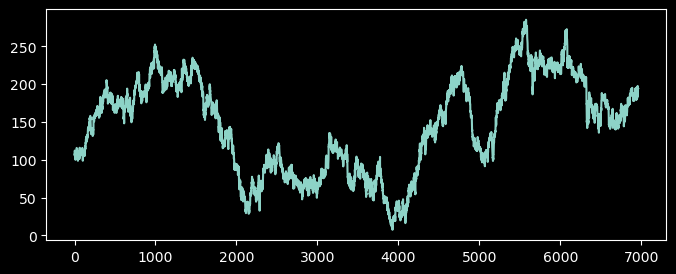

Simulation stopped.


In [29]:
book = OrderBook()
noise = MarketNoise()

exchange = AsyncExchange(book, noise)

try:
    await exchange.run_simulation()
except KeyboardInterrupt:
    exchange.running = False

<a id="section_4"></a>
### Debugging


#### Old code: visualisations for debugging LOB logic

In [358]:
#import random
book = OrderBook()

t = 0
T = 10_000  # simulation horizon
order_times = []
order_events = []
order_intervals = []
mid_series = []

while t < T:

    imbalance = book.compute_imbalance()

    # 2. event type
    λ_market_buy = 0.1 + 3.0 * max(imbalance, 0)
    λ_market_sell = 0.1 + 3.0 * max(-imbalance, 0)
    
    λ_limit_buy = 0.3 + 0.5 * (1 - imbalance)
    λ_limit_sell = 0.3 + 0.5 * (1 + imbalance)
    
    λ_cancel_buy  = 0.2 + 0.8 * max(-imbalance, 0)
    λ_cancel_sell = 0.2 + 0.8 * max(imbalance, 0)

    events = [
        "limit_buy","limit_sell",
        "market_buy","market_sell",
        "cancel_buy","cancel_sell"
    ]
    
    lambdas = [
        λ_limit_buy, λ_limit_sell,
        λ_market_buy, λ_market_sell,
        λ_cancel_buy, λ_cancel_sell
    ]
    
    probs = np.array(lambdas) / sum(lambdas)

    event = np.random.choice(events, p=probs)
    
    # 1. time jump
    dt = np.random.exponential(1 / sum(lambdas))
    t += dt

    # 3. execute event
    if event == "limit_buy":

        price = book.sample_price("buy")
        if price < 0: print(price)
        # qty = np.random.randint(1, 10)
        qty = max(1, int(np.random.normal(loc=3, scale=1)) + 1)
        book.add_limit("buy", price, qty)
    
    
    elif event == "limit_sell":

        price = book.sample_price("sell")
        if price < 0: print(price)
        # qty = np.random.randint(1, 10)
        qty = max(1,int(np.random.normal(loc=3, scale=1)) + 1)
        book.add_limit("sell", price, qty)
    
    
    elif event == "market_buy":

        # qty = np.random.randint(1, 10)
        qty = max(1,int(np.random.lognormal(mean=3, sigma=1)) + 1)   # small but occasionally huge orders
        book.market_order("buy", qty)
    
    
    elif event == "market_sell":

        # qty = np.random.randint(1, 10)
        qty = max(1,int(np.random.lognormal(mean=3, sigma=1)) + 1)
        book.market_order("sell", qty)
    
    elif event == "cancel_buy":
        
        book.cancel_side("buy")
    
    elif event == "cancel_sell":
        
        book.cancel_side("sell")

    order_times.append(t)
    order_events.append(event)
    order_intervals.append(dt)

    mid_series.append(book.to_price(book.mid))

<Axes: >

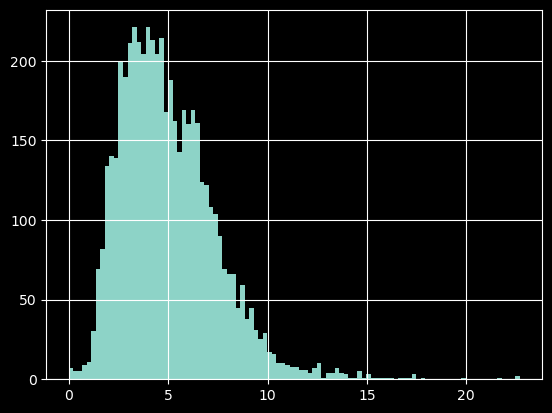

In [362]:
df = book.trades_df()
df['slippage'].hist(bins = 100)

In [364]:
df['is_one_sided'] = df['bid_after'].isna() | df['ask_after'].isna() | \
                     df['bid_before'].isna() | df['ask_before'].isna()

# Add a categorical column for easier plotting
df['regime'] = np.where(df['is_one_sided'], 'Stress (One-Sided)', 'Normal (Liquid)')

# Filter for normal liquidity and small orders
liquid_small_orders = df[(df['is_one_sided'] == False) & (df['book_penet'] < 1)]

# This correlation SHOULD be near 0 or NaN if Impact is always 0
corr_clean = liquid_small_orders['impact'].corr(liquid_small_orders['slippage'])
print(f"Clean Regime Correlation: {corr_clean}")

# In the world of data science and trading simulations, 
# a NaN correlation in your "Clean" regime is actually a badge of honor. It means your code is finally doing exactly what it should:
# clean regime: In market microstructure, a "Clean Regime" refers to a state where the order book is Liquid and Balanced.
# this means Two-Sided Liquidity: Both best_bid and best_ask exist. The market has a clear "anchor" (the spread).
# In the actual data, there was pollution in that impact was non zero when book penet < 1 when this should not happen. THis happened because
# at least one side of the book was empty

Clean Regime Correlation: nan


C:\Users\Raymon\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Raymon\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


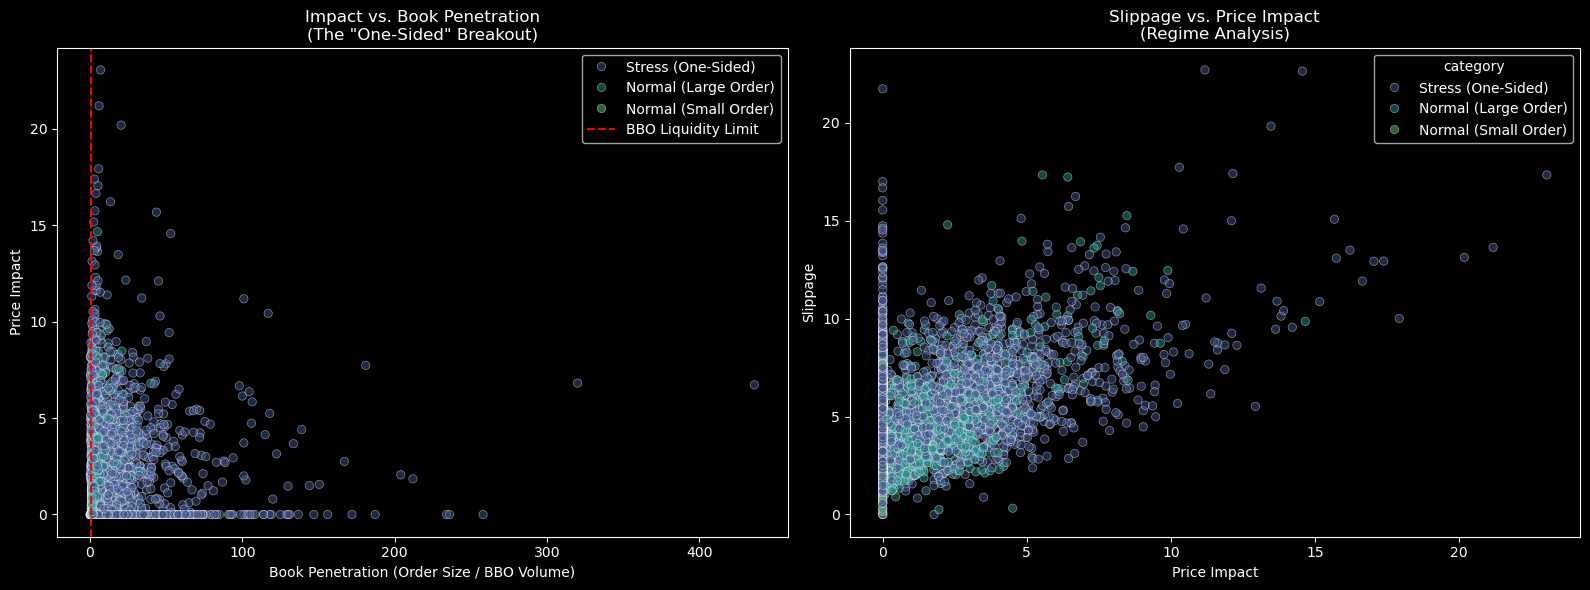

--- Correlation Breakdown ---
Global Correlation: 0.4662
Clean Small Orders (Penet < 1): nan
Normal Large Orders (Penet >= 1): 0.6312
Stress Regime (One-Sided): 0.4592


C:\Users\Raymon\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Raymon\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [366]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# One-Sided explains why some small orders still have impact
df['is_one_sided'] = df['bid_after'].isna() | df['ask_after'].isna() | \
                     df['bid_before'].isna() | df['ask_before'].isna()

df['is_impactful'] = df['book_penet'] >= 1

def get_label(row):
    if row['is_one_sided']: return 'Stress (One-Sided)'
    if row['is_impactful']: return 'Normal (Large Order)'
    return 'Normal (Small Order)'

df['category'] = df.apply(get_label, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Step Function of Impact
# Now shows how "One-Sided" books break the 0-impact rule for small orders
sns.scatterplot(data=df, x='book_penet', y='impact', hue='category', 
                alpha=0.5, palette='viridis', ax=ax1)
ax1.axvline(1, color='red', linestyle='--', label='BBO Liquidity Limit')
ax1.set_title('Impact vs. Book Penetration\n(The "One-Sided" Breakout)')
ax1.set_xlabel('Book Penetration (Order Size / BBO Volume)')
ax1.set_ylabel('Price Impact')
ax1.legend()

# Plot B: The Correlation Breakdown
# This will show the vertical line at Impact=0 for the "Clean" group
sns.scatterplot(data=df, x='impact', y='slippage', hue='category', 
                alpha=0.5, palette='viridis', ax=ax2)
ax2.set_title('Slippage vs. Price Impact\n(Regime Analysis)')
ax2.set_xlabel('Price Impact')
ax2.set_ylabel('Slippage')

plt.tight_layout()
plt.show()

# print the Correlation Breakdown
print("--- Correlation Breakdown ---")
print(f"Global Correlation: {df['impact'].corr(df['slippage']):.4f}")

# clean group (Should be NaN or 0 if impact is truly 0)
clean_small = df[(df['book_penet'] < 1) & (df['is_one_sided'] == False)]
print(f"Clean Small Orders (Penet < 1): {clean_small['impact'].corr(clean_small['slippage'])}")

# whale group (Walking the levels)
whales = df[(df['book_penet'] >= 1) & (df['is_one_sided'] == False)]
print(f"Normal Large Orders (Penet >= 1): {whales['impact'].corr(whales['slippage']):.4f}")

# stress group (One-sided books)
stress = df[df['is_one_sided'] == True]
print(f"Stress Regime (One-Sided): {stress['impact'].corr(stress['slippage']):.4f}")

In [368]:
print(df.groupby("side")["slippage"].count())
print(df.groupby("side")["slippage"].mean())

side
buy     2584
sell    2638
Name: slippage, dtype: int64
side
buy     5.004013
sell    5.054276
Name: slippage, dtype: float64


In [370]:
count_dict = defaultdict(int)
for order in order_events:
    count_dict[order] += 1
count_dict

defaultdict(int,
            {'limit_buy': 8057,
             'market_buy': 7958,
             'limit_sell': 7969,
             'cancel_sell': 3815,
             'cancel_buy': 3929,
             'market_sell': 8464})

<Axes: >

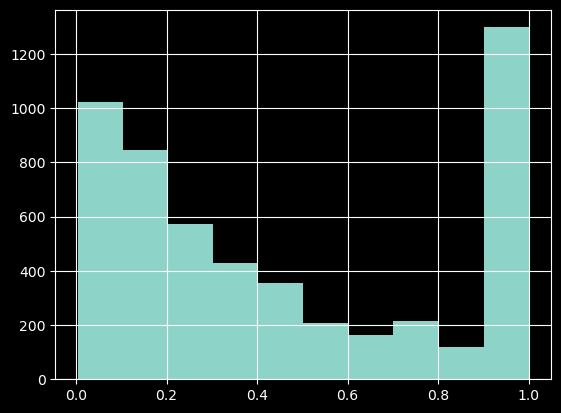

In [372]:
df["fill_ratio"].hist()

<Axes: xlabel='fill_ratio', ylabel='slippage'>

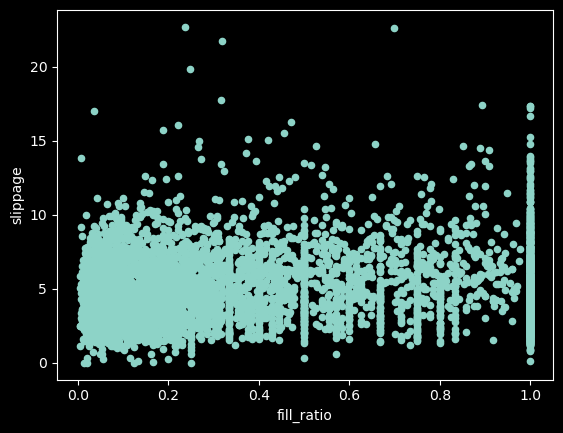

In [374]:
# fill ratio of 1 has a wide spread of slippage. “100% fill” doesn’t imply “good execution.”
df.plot.scatter(x="fill_ratio", y="slippage")

In [376]:
print("slippage by filled quantity")
print(df.groupby(pd.qcut(df["filled_qty"], 4))["slippage"].mean())
    
print("impact by fill quantity")
print(df.groupby(pd.qcut(df["filled_qty"], 4))["impact"].mean())

slippage by filled quantity
filled_qty
(0.999, 3.0]    4.338857
(3.0, 5.0]      4.363488
(5.0, 10.0]     5.277965
(10.0, 87.0]    6.517699
Name: slippage, dtype: float64
impact by fill quantity
filled_qty
(0.999, 3.0]    0.268839
(3.0, 5.0]      0.407269
(5.0, 10.0]     1.877945
(10.0, 87.0]    3.598043
Name: impact, dtype: float64


C:\Users\Raymon\AppData\Local\Temp\ipykernel_29488\44591004.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df["filled_qty"], 4))["slippage"].mean())
C:\Users\Raymon\AppData\Local\Temp\ipykernel_29488\44591004.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df["filled_qty"], 4))["impact"].mean())


In [378]:
print(df.groupby("event")["impact"].mean())
df["price_moved"] = df["mid_after"] != df["mid_before"]
df.groupby("event")["price_moved"].mean()

event
limit     1.800404
market    1.356179
Name: impact, dtype: float64


event
limit     0.626263
market    0.455025
Name: price_moved, dtype: float64

In [380]:
print(df.groupby("event")["impact per unit"].mean())
df["price_moved"] = df["mid_after"] != df["mid_before"]
df.groupby("event")["price_moved"].mean()

event
limit     0.647075
market    0.120016
Name: impact per unit, dtype: float64


event
limit     0.626263
market    0.455025
Name: price_moved, dtype: float64

In [382]:
print(df.groupby("event")["qty"].mean())
print(df.groupby("event")["filled_qty"].mean())

event
limit      3.525253
market    33.588629
Name: qty, dtype: float64
event
limit     3.000000
market    8.171777
Name: filled_qty, dtype: float64


In [384]:
df["spread_before"] = df["ask_before"] - df["bid_before"]
print(df.groupby("event")["spread_before"].mean())

event
limit     702.103960
market    765.454246
Name: spread_before, dtype: float64


In [386]:
df["signed_impact"] = df["impact"] * np.sign(df["signed_qty"])
df["signed_impact"].mean()

0.012527767139027188

<Axes: xlabel='slippage', ylabel='impact'>

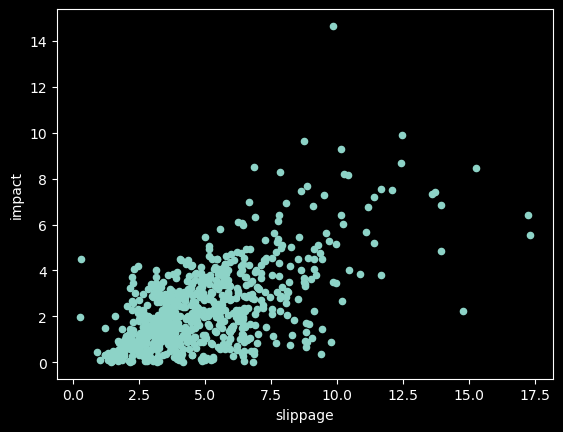

In [388]:
# there will be an anchor at impact = 0 because of book penet < 1 observations
# df_isolated = df[(df['is_one_sided'] == False)]
df_isolated = df[(df['is_one_sided'] == False) & (df['book_penet'] > 1)]
df_isolated.plot.scatter(x="slippage", y="impact")

<Axes: xlabel='fill_ratio', ylabel='slippage'>

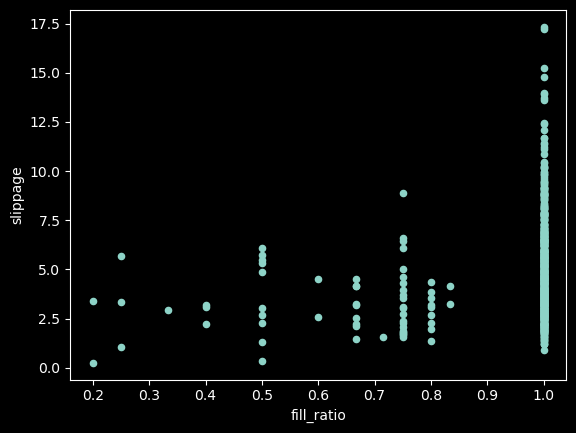

In [390]:
df_isolated.plot.scatter(x="fill_ratio", y="slippage")

<Axes: >

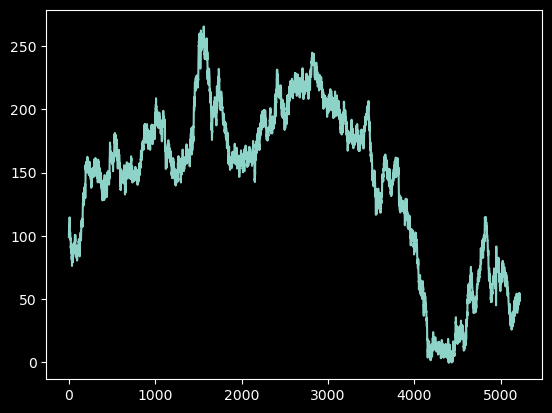

In [392]:
# note that this mid_after chart is based on the trades done, not the full movement of the mid.
df["mid_after"].plot()

<Axes: >

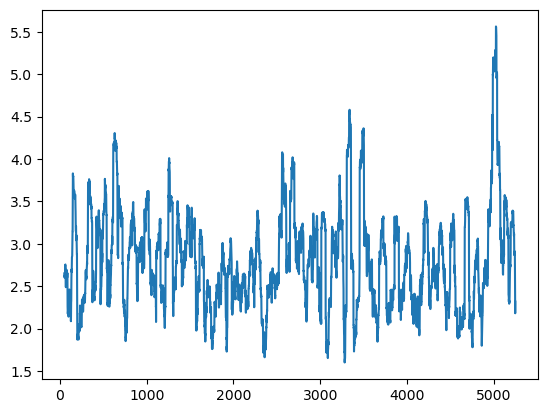

In [468]:
df["ret"] = df["mid_after"].diff()
df["ret"].rolling(50).std().plot()

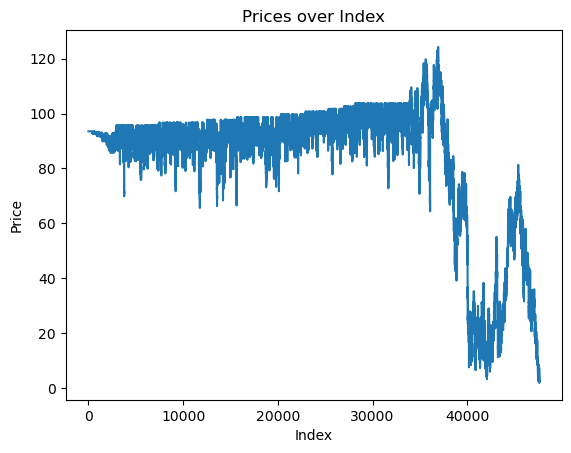

In [474]:
# price path move
import matplotlib.pyplot as plt

plt.plot(mid_series)  # x-axis will be [0, 1, 2, ...]
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Prices over Index")
plt.show()

In [277]:
plt.hist(order_times_subset, bins=20, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

NameError: name 'order_times_subset' is not defined

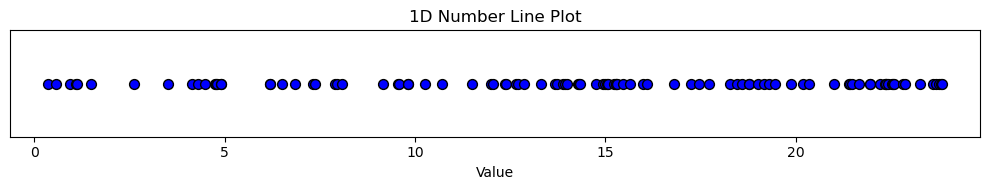

In [279]:
# Create the plot
plt.figure(figsize=(10, 2))

# Plot the numbers with y-coordinates set to 0
plt.scatter(order_times[:101], np.zeros_like(order_times[:101]), color='blue', s=50, edgecolors='black')

# Hide the y-axis entirely
plt.gca().get_yaxis().set_visible(False)

plt.xlim(min(order_times[:101]) - 1, max(order_times[:101]) + 1)

# Label the x-axis
plt.xlabel("Value")
plt.title("1D Number Line Plot")

plt.tight_layout()
plt.show()

#### Old code: debugging LOB functionality

In [202]:
print(book.best_ask())
print(book.best_bid())
print(book.mid)

10012
10009
10010.5


In [470]:
book.asks

SortedDict({-6238: deque([{'id': 15921, 'qty': 4}])})

In [472]:
book.bids

SortedDict({-9102: deque([{'id': 15907, 'qty': 3}]), -8554: deque([{'id': 15897, 'qty': 4}]), -8384: deque([{'id': 15889, 'qty': 1}]), -8080: deque([{'id': 15914, 'qty': 3}]), -8010: deque([{'id': 15912, 'qty': 1}, {'id': 15917, 'qty': 4}]), -7923: deque([{'id': 15913, 'qty': 3}]), -7445: deque([{'id': 15919, 'qty': 3}])})

In [232]:
df[df['impact'] < 0].head()

,order_id,event,side,qty,filled_qty,fill_ratio,avg_price,mid_before,mid_after,slippage,impact,signed_qty,signed_impact,price_moved,ret,ret_5


In [474]:
book.analytics.records

[{'order_id': 6,
  'event': 'market',
  'side': 'sell',
  'qty': 18,
  'filled_qty': 3,
  'fill_ratio': 0.16666666666666666,
  'avg_price': 85.48,
  'bid_before': 8548,
  'bid_after': None,
  'ask_before': 9311,
  'ask_after': 9311,
  'mid_before': 89.3,
  'mid_after': 89.3,
  'slippage': 3.81,
  'impact': -0.0,
  'impact per unit': -0.0,
  'signed_qty': -18},
 {'order_id': 7,
  'event': 'market',
  'side': 'sell',
  'qty': 65,
  'filled_qty': 4,
  'fill_ratio': 0.06153846153846154,
  'avg_price': 79.09,
  'bid_before': 7909,
  'bid_after': None,
  'ask_before': 9311,
  'ask_after': 9311,
  'mid_before': 86.1,
  'mid_after': 86.1,
  'slippage': 7.01,
  'impact': -0.0,
  'impact per unit': -0.0,
  'signed_qty': -65},
 {'order_id': 9,
  'event': 'market',
  'side': 'sell',
  'qty': 7,
  'filled_qty': 7,
  'fill_ratio': 1.0,
  'avg_price': 83.28,
  'bid_before': 8431,
  'bid_after': 8190,
  'ask_before': 9311,
  'ask_after': 9311,
  'mid_before': 88.71,
  'mid_after': 87.5,
  'slippage': 

In [476]:
book.trades_done

defaultdict(collections.deque,
            {8548: deque([{'id': 6, 'qty': 3, 'close type': 'market'},
                    {'id': 13144, 'qty': 27, 'close type': 'market'}]),
             7909: deque([{'id': 7, 'qty': 4, 'close type': 'market'}]),
             8190: deque([{'id': 9, 'qty': 7, 'close type': 'market'},
                    {'id': 9, 'qty': 1, 'close type': 'market'}]),
             9311: deque([{'id': 11, 'qty': 4, 'close type': 'market'}]),
             8631: deque([{'id': 14, 'qty': 7, 'close type': 'market'},
                    {'id': 6608, 'qty': 4, 'close type': 'market'},
                    {'id': 7410, 'qty': 11, 'close type': 'market'}]),
             8531: deque([{'id': 19, 'qty': 5, 'close type': 'market'}]),
             9161: deque([{'id': 28, 'qty': 11, 'close type': 'market'},
                    {'id': 7414, 'qty': 2, 'close type': 'market'}]),
             8735: deque([{'id': 32, 'qty': 4, 'close type': 'limit'}]),
             9561: deque([{'id': 32, 'qt

In [ ]:
book = OrderBook()

# means of the poisson events. Cancel is lower than market order, which is lower than limit
# what are the units of these?
# λ_limit = 0.6
# λ_market = 0.25
# λ_cancel = 0.15

imbalance = book.compute_imbalance()

λ_market_buy = 0.2 + 1.5 * max(imbalance, 0)
λ_market_sell = 0.2 + 1.5 * max(-imbalance, 0)

λ_limit_buy = 0.5 * (1 - imbalance)
λ_limit_sell = 0.5 * (1 + imbalance)


events = ["limit","market","cancel"]
probs = [λ_limit, λ_market, λ_cancel]  # these are probabilities of choosing which event when an event does happen

probs = np.array(probs)/sum(probs)

# for t in range(10000):

#     # events are orders hitting the book
#     event = np.random.choice(events, p=probs)

#     if event == "limit":

#         side = np.random.choice(["buy","sell"]) # order side selection uses uniform distribution

#         # price is uniform distribution around mid
#         price = book.sample_price(side)

#         # quantity is uniform distribution
#         qty = np.random.randint(1,10)

#         # add limit order to book
#         book.add_limit(side, price, qty)

    
#     elif event == "market":

#         # uniform distribution for order side selection
#         side = np.random.choice(["buy","sell"])
#         # uniform distribution for order quantity
#         # should probably change this modelling to allow large orders to hit the books
#         qty = np.random.randint(1,10)

#         # returns trades list from market orders
#         trades = book.market_order(side, qty)

#     else:
#         book.cancel_random()